In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.neighbors import KNeighborsClassifier


In [2]:
df=sns.load_dataset("titanic")
df

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,0,2,male,27.0,0,0,13.0000,S,Second,man,True,NaN,Southampton,no,True
887,1,1,female,19.0,0,0,30.0000,S,First,woman,False,B,Southampton,yes,True
888,0,3,female,NaN,1,2,23.4500,S,Third,woman,False,NaN,Southampton,no,False
889,1,1,male,26.0,0,0,30.0000,C,First,man,True,C,Cherbourg,yes,True


In [3]:
df=df.iloc[:,0:9]


In [4]:
df.shape

(891, 9)

In [5]:
df.isnull().sum()

survived      0
pclass        0
sex           0
age         177
sibsp         0
parch         0
fare          0
embarked      2
class         0
dtype: int64

In [6]:
df.isnull().sum().sum()
df['age']=df['age'].fillna(df['age'].median())
df.dropna(inplace=True)

In [7]:
df.isnull().sum()

survived    0
pclass      0
sex         0
age         0
sibsp       0
parch       0
fare        0
embarked    0
class       0
dtype: int64

In [8]:
df.duplicated().sum()

np.int64(116)

In [9]:
df.drop_duplicates(inplace=True)

In [10]:
df.duplicated().sum()

np.int64(0)

In [11]:
df.columns

Index(['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare',
       'embarked', 'class'],
      dtype='object')

In [12]:
from sklearn.preprocessing import LabelEncoder
sex_encoder=LabelEncoder()
embarked_encoder=LabelEncoder()
class_encoder=LabelEncoder()

df['sex']=sex_encoder.fit_transform(df['sex'])
df['embarked']=embarked_encoder.fit_transform(df['embarked'])
df['class']=class_encoder.fit_transform(df['class'])

In [13]:
x=df.iloc[:,1:]
y=df['survived']

In [14]:
x

,pclass,sex,age,sibsp,parch,fare,embarked,class
0,3,1,22.0,1,0,7.2500,2,2
1,1,0,38.0,1,0,71.2833,0,0
2,3,0,26.0,0,0,7.9250,2,2
3,1,0,35.0,1,0,53.1000,2,0
4,3,1,35.0,0,0,8.0500,2,2
...,...,...,...,...,...,...,...,...
885,3,0,39.0,0,5,29.1250,1,2
887,1,0,19.0,0,0,30.0000,2,0
888,3,0,28.0,1,2,23.4500,2,2
889,1,1,26.0,0,0,30.0000,0,0


In [15]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

Knn=KNeighborsClassifier(n_neighbors=5,p=1,weights='distance')
Knn.fit(x_train,y_train)



,n_neighbors,5
,weights,'distance'
,algorithm,'auto'
,leaf_size,30
,p,1
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [16]:
y_pred=Knn.predict(x_test)

In [17]:
from sklearn.metrics import accuracy_score,roc_auc_score,confusion_matrix,classification_report,roc_curve

In [18]:
from sklearn.model_selection import GridSearchCV
param={'n_neighbors':[3,5,7,9,11],
       'p':[1,2],
       'weights':['uniform','distance']}


In [19]:
model=GridSearchCV(Knn,param_grid=param,cv=5,n_jobs=-1)
model.fit(x_train,y_train)

,estimator,KNeighborsCla...ts='distance')
,param_grid,"{'n_neighbors': [3, 5, ...], 'p': [1, 2], 'weights': ['uniform', 'distance']}"
,scoring,None
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,n_neighbors,11


In [20]:
accuracy_score(y_test,y_pred)

0.7354838709677419

In [21]:
roc_auc_score(y_test,y_pred)

0.7349317349317349

In [22]:
confusion_matrix(y_test,y_pred)

array([[64, 14],
       [27, 50]])

In [23]:
fpr,tpr,thre=roc_curve(y_test,y_pred)

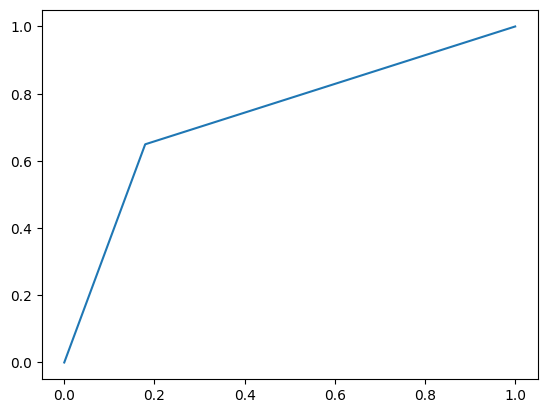

In [24]:
plt.plot(fpr,tpr)
plt.show()

In [25]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

training_accuracy = []
testing_accuracy = []

for k in range(1, 20):
    knn = KNeighborsClassifier(n_neighbors=k, metric="minkowski", p=2)
    knn.fit(x_train, y_train)
    
    # Training accuracy
    y_train_pred = knn.predict(x_train)
    training_accuracy.append(accuracy_score(y_train, y_train_pred))
    
    # Testing accuracy
    y_test_pred = knn.predict(x_test)
    testing_accuracy.append(accuracy_score(y_test, y_test_pred))


In [26]:
for i,j in zip(training_accuracy,testing_accuracy):
    print(i,j)

0.9789644012944984 0.6387096774193548
0.8106796116504854 0.6387096774193548
0.8252427184466019 0.6516129032258065
0.7880258899676376 0.6387096774193548
0.7783171521035599 0.6580645161290323
0.7427184466019418 0.6709677419354839
0.7572815533980582 0.6838709677419355
0.7362459546925566 0.6645161290322581
0.7394822006472492 0.6645161290322581
0.7378640776699029 0.6387096774193548
0.7459546925566343 0.6451612903225806
0.7330097087378641 0.6193548387096774
0.7491909385113269 0.632258064516129
0.7216828478964401 0.6387096774193548
0.7265372168284789 0.6387096774193548
0.7200647249190939 0.6193548387096774
0.7265372168284789 0.6129032258064516
0.7216828478964401 0.6258064516129033
0.7281553398058253 0.6193548387096774


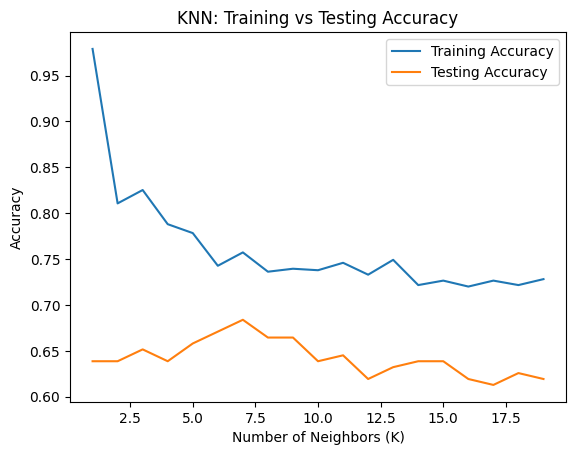

In [27]:
import matplotlib.pyplot as plt

k_values = range(1, 20,)

plt.figure()
plt.plot(k_values, training_accuracy, label="Training Accuracy")
plt.plot(k_values, testing_accuracy, label="Testing Accuracy")

plt.xlabel("Number of Neighbors (K)")
plt.ylabel("Accuracy")
plt.title("KNN: Training vs Testing Accuracy")
plt.legend()
plt.show()


In [30]:
# # plot
# import matplotlib.pyplot as plt
# sns.lineplot(range(1,20,2),y=training_accuracy,color='g')
# sns.lineplot(range(1,20,2),y=testing_accuracy,color='r')
# plt.show()